In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson, binom, geom, multinomial, kstest

# 🛫 Gerenciamento de Operações em um Aeroporto
## Introdução

Este notebook apresenta uma análise estatística das operações de um aeroporto internacional utilizando diferentes distribuições probabilísticas para analisar diferentes indicadores.

## 🔎 Distribuição Normal: Análise dos Tempos de Check-in

Os tempos de check-in dos passageiros variam e podem ser influenciados por vários fatores, como o horário do dia ou a classe de viagem. 

Os dados foram simulados utilizando uma distribuição normal com média 20 minutos e desvio padrão 5 minutos.

Observa-se pelo histograma que a distribuição apresenta formato aproximadamente simétrico, característico da distribuição normal.

Essa modelagem é adequada porque tempos de atendimento tendem a variar em torno de uma média, influenciados por múltiplos fatores independentes.

In [2]:
np.random.seed(42) #seed: gerante q são gerados sempre os mesmos números

checkin = np.random.normal(loc=20, scale=5, size=1000) #média de 20min, desvio padrão de 5min, 1000 passageiros

checkin[:10]

array([22.48357077, 19.30867849, 23.23844269, 27.61514928, 18.82923313,
       18.82931522, 27.89606408, 23.83717365, 17.65262807, 22.71280022])

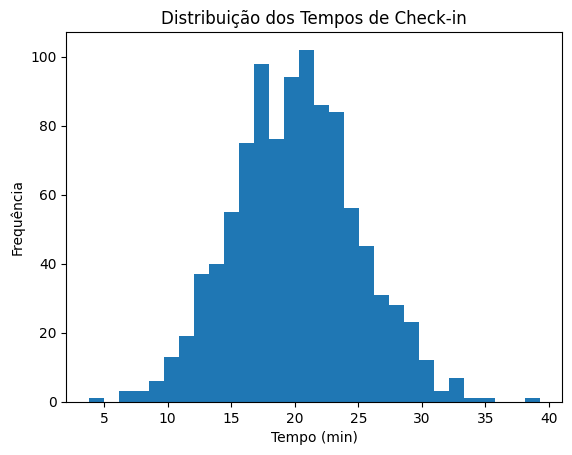

In [3]:
plt.hist(checkin, bins=30)
plt.title("Distribuição dos Tempos de Check-in")
plt.xlabel("Tempo (min)")
plt.ylabel("Frequência")
plt.show()

### Formalização do modelo

Os tempos de check-in foram modelados como uma variável aleatória contínua seguindo uma distribuição Normal:
```
𝑇∼𝑁(𝜇^,𝜎^)
```
Onde:

μ̂ representa o tempo médio estimado de check-in.
σ̂ representa a variabilidade estimada nos tempos de atendimento.

O desvio padrão foi calculado utilizando a correção de Bessel (ddof=1), pois estamos trabalhando com uma amostra e não com a população completa.

### Justificativa da escolha da Normal
A distribuição Normal é adequada para modelar tempos de atendimento quando estes resultam da soma de múltiplos fatores independentes (experiência do atendente, fluxo de passageiros, tipo de bagagem etc.), o que é consistente com o Teorema Central do Limite.

### Interpretação operacional dos parâmetros
O tempo médio de check-in é aproximadamente 20 minutos, com variação típica de cerca de 5 minutos. Isso indica que a maioria dos passageiros é atendida em um intervalo entre aproximadamente 15 e 25 minutos (μ ± σ).

In [4]:
mu = np.mean(checkin)  #média estimada
sigma = np.std(checkin, ddof=1) #desvio padrão estimado - correção de Bessel
mu, sigma

(np.float64(20.096660279111628), np.float64(4.896079690898378))

In [5]:
mu_hat, sigma_hat = norm.fit(checkin)
mu_hat, sigma_hat

(np.float64(20.096660279111628), np.float64(4.893631038736771))

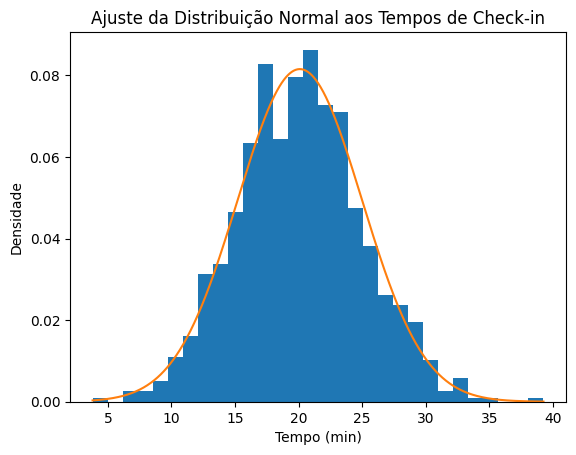

In [6]:
plt.hist(checkin, bins=30, density=True)

mu_hat, sigma_hat = norm.fit(checkin)
x = np.linspace(min(checkin), max(checkin), 1000)
y = norm.pdf(x, mu_hat, sigma_hat)

plt.plot(x, y)
plt.title("Ajuste da Distribuição Normal aos Tempos de Check-in")
plt.xlabel("Tempo (min)")
plt.ylabel("Densidade")
plt.show()

### 📌 Análise de Aderência — Teste de Kolmogorov-Smirnov

Para verificar se os tempos de check-in seguem adequadamente uma distribuição Normal, foi aplicado o teste de Kolmogorov-Smirnov (KS).

O teste de Kolmogorov-Smirnov compara a distribuição empírica dos dados observados com a distribuição teórica especificada (neste caso, a Normal ajustada). Ele mede a maior diferença absoluta entre as duas funções de distribuição acumulada.

As hipóteses do teste são:

* H₀ (hipótese nula): os dados seguem a distribuição Normal especificada.
* H₁ (hipótese alternativa): os dados não seguem essa distribuição.

O resultado obtido foi:

* Estatística KS = 0.0215
* p-valor = 0.737

Como o p-valor é superior ao nível de significância usual de 5% (α = 0.05), não há evidência estatística para rejeitar a hipótese nula.

Portanto, o modelo Normal ajustado apresenta boa aderência aos dados simulados de tempo de check-in. Isso reforça a adequação da distribuição Normal como modelo probabilístico para análise de tempos extremos e planejamento operacional.
Porém, embora o modelo Normal tenha apresentado boa aderência, tempos de atendimento podem apresentar assimetria em cenários reais, especialmente em períodos de alta demanda.

In [7]:
kstest(checkin, 'norm', args=(mu_hat, sigma_hat))

KstestResult(statistic=np.float64(0.021479979161405816), pvalue=np.float64(0.7369569123250277), statistic_location=np.float64(17.801344708629124), statistic_sign=np.int8(1))

### 🎯 Probabilidades de eventos extremos

* Mais de 30 minutos de check-in
* Menos de 10 minutos (atendimento muito rápido)

In [8]:
#>30min check-in
prob_30 = 1 - norm.cdf(30, mu_hat, sigma_hat)
prob_30

np.float64(0.02149947725581769)

In [9]:
# <10min check-in
prob_10 = norm.cdf(10, mu_hat, sigma_hat)
prob_10

np.float64(0.019545643700477625)

### 📌 Intervalo central de 95%

In [10]:
limite_inferior = norm.ppf(0.025, mu_hat, sigma_hat)
limite_superior = norm.ppf(0.975, mu_hat, sigma_hat)

limite_inferior, limite_superior

(np.float64(10.50531968956022), np.float64(29.688000868663032))

### 📊 Conclusão
A probabilidade estimada de um passageiro ultrapassar 30 minutos no check-in é de aproximadamente 2,15%.
Considerando um fluxo diário de 8.000 passageiros, estima-se que cerca de 172 passageiros possam enfrentar atrasos significativos, o que pode indicar necessidade de reforço operacional em horários de pico.

## 🔎 Distribuição de Poisson — Aterrissagens de Emergência

Emergências que requerem aterrissagens não são comuns, mas seguem um padrão que pode ser estudado. 

Para modelar as aterrissagens de emergência, foi utilizada a Distribuição de Poisson, adequada para eventos raros e independentes ao longo do tempo.

Na Distribuição de Poisson (Diferente da Normal, aqui não existe σ separado):
```
𝜆 = taxa média real de eventos por período (xˉ)
```
e 
```
média = variância = λ
```

Foi considerada uma média histórica de 2 ocorrências por mês e 60 meses de operação (5 anos) para obter uma base estatística consistente.

In [11]:
np.random.seed(42)
emergencias = np.random.poisson(lam=2, size=60)  # 5 anos de dados mensais
lambda_hat = np.mean(emergencias)

print("Primeiros 10 meses:", emergencias[:10])
print("Média estimada (λ̂):", lambda_hat)
print("Variância:", np.var(emergencias))

Primeiros 10 meses: [4 1 3 3 1 2 1 1 2 2]
Média estimada (λ̂): 1.9333333333333333
Variância: 1.6955555555555553


A média estimada (1,93) é próxima da variância observada (1,70), o que está em conformidade com a propriedade fundamental da Distribuição de Poisson, onde média e variância são iguais na população. Pequenas diferenças são esperadas devido à variabilidade amostral.

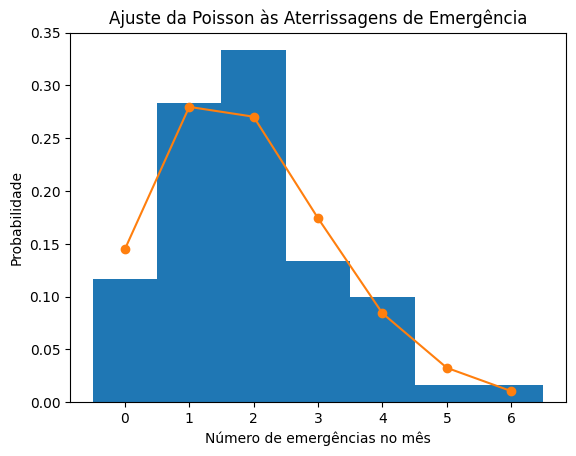

In [12]:
valores = np.arange(0, max(emergencias)+1)

plt.hist(emergencias, bins=range(0, max(emergencias)+2), density=True, align='left')

plt.plot(valores, poisson.pmf(valores, lambda_hat), marker='o')

plt.title("Ajuste da Poisson às Aterrissagens de Emergência")
plt.xlabel("Número de emergências no mês")
plt.ylabel("Probabilidade")
plt.show()

## 📊 Ajuste da Poisson às Aterrissagens de Emergência

Os dados simulados representando o número de aterrissagens de emergência por mês foram modelados utilizando a Distribuição de Poisson. A média estimada obtida foi λ̂ = 1,93 emergências por mês.

Uma característica fundamental da distribuição de Poisson é que média e variância são iguais na população. Nos dados simulados observou-se:

Média: 1,93

Variância: 1,70

A proximidade entre esses valores indica que o comportamento dos dados é compatível com o modelo de Poisson, sendo a pequena diferença esperada devido à variabilidade amostral.

A análise gráfica também reforça esse resultado. No histograma observado, a distribuição empírica das emergências mensais acompanha de forma razoável a curva de probabilidade da Poisson ajustada. A maior concentração de ocorrências está entre 1 e 2 emergências por mês, enquanto valores mais altos aparecem com probabilidade progressivamente menor.

Do ponto de vista operacional, esse modelo permite estimar a frequência esperada de eventos de emergência e apoiar o planejamento de recursos aeroportuários. Por exemplo, sabendo que a média é aproximadamente duas emergências mensais, a administração do aeroporto pode dimensionar equipes de resposta, equipamentos e protocolos de segurança adequados para lidar com esse nível de ocorrência.

Assim, a Distribuição de Poisson se mostra um modelo apropriado para representar a contagem de aterrissagens de emergência ao longo do tempo, contribuindo para a análise probabilística e a tomada de decisão na gestão operacional do aeroporto.

### 🎯 Probabilidade Operacional

In [13]:
# probabilidade de ter 4 ou mais emergências em um mês
prob = poisson.sf(3, lambda_hat)

print(f"Probabilidade: {prob:.3f} ({prob*100:.1f}%)")

Probabilidade: 0.131 (13.1%)


Existe aproximadamente 13,1% de chance de ocorrerem quatro ou mais emergências em um mês, indicando que esse tipo de evento é relativamente incomum, mas possível dentro da operação do aeroporto.

## 🔎 Binomial — Sucesso na Segurança
### Simulação de um dia de inspeções
Definir dois parâmetros da binomial:

* **n** = número de inspeções no dia
* **p** = probabilidade de detectar corretamente uma ameaça

Exemplo plausível:
* 200 inspeções por dia
* 95% de chance de detectar corretamente

In [14]:
n = 200   # inspeções por dia
p = 0.95  # probabilidade de sucesso (detectar corretamente)

prob_190 = binom.pmf(190, n, p)
print(f"Probabilidade de detectar exatamente 190 ameaças: {prob_190:.3f} ({prob_190*100:.1f}%)")

prob_190_ou_mais = binom.sf(189, n, p)

print(f"Probabilidade de detectar pelo menos 190 ameaças: {prob_190_ou_mais:.3f} ({prob_190_ou_mais*100:.1f}%)")

Probabilidade de detectar exatamente 190 ameaças: 0.128 (12.8%)
Probabilidade de detectar pelo menos 190 ameaças: 0.583 (58.3%)


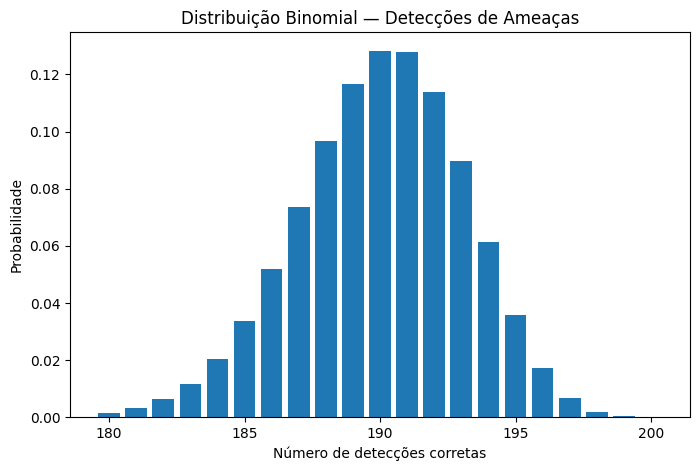

In [15]:
# valores possíveis de sucessos
x = np.arange(180, 201)

# probabilidade binomial
y = binom.pmf(x, n, p)

plt.figure(figsize=(8,5))
plt.bar(x, y)

plt.title("Distribuição Binomial — Detecções de Ameaças")
plt.xlabel("Número de detecções corretas")
plt.ylabel("Probabilidade")

plt.show()

### 📊 Modelagem Binomial

Cada inspeção de segurança foi modelada como um ensaio de Bernoulli, no qual o sucesso corresponde à identificação correta de uma ameaça. Considerando um dia com 200 inspeções e uma probabilidade de detecção correta de 95%, o número total de sucessos pode ser modelado por uma distribuição binomial.

O valor esperado de detecções corretas é:
```
E(X)=np=200×0.95=190
```
Além disso, foi calculada a probabilidade de ocorrerem 190 ou mais detecções corretas em um dia, permitindo avaliar o desempenho esperado do sistema de segurança.

Essa modelagem ajuda a compreender o nível de confiabilidade dos procedimentos de inspeção e pode auxiliar na definição de padrões operacionais e metas de desempenho.

O gráfico da distribuição binomial mostra a probabilidade de diferentes números de detecções corretas ao longo de um dia de operação. Observa-se que o valor mais provável está próximo de 190 detecções, que corresponde ao valor esperado da distribuição (np). Valores muito abaixo desse número apresentam probabilidades significativamente menores, indicando que o sistema de segurança tende a manter um desempenho consistente.

## 🔎 Distribuição Bernoulli: Decisão de Direcionamento de Bagagens
Cada bagagem pode ter apenas dois resultados:

* 1 → direcionada corretamente
* 0 → direcionada incorretamente

Isso é exatamente um experimento de Distribuição de Bernoulli (Bernoulli é um caso especial da Binomial com n = 1)

Supondo:

* probabilidade(p) de direcionamento correto = 0.98

* serão analisadas 500 bagagens(n)

### 📌 Eficiência do sistema

In [16]:
p = 0.98
n = 500

np.random.seed(42)
bagagens = np.random.binomial(1, p, size=n)

taxa_sucesso = np.mean(bagagens)

print(f"Taxa de direcionamento correto: {taxa_sucesso:.4f}({taxa_sucesso*100:.1f}%)")

Taxa de direcionamento correto: 0.9840(98.4%)


### 📌 Sucessos e falhas

Bagagens corretas: 492
Bagagens incorretas: 8


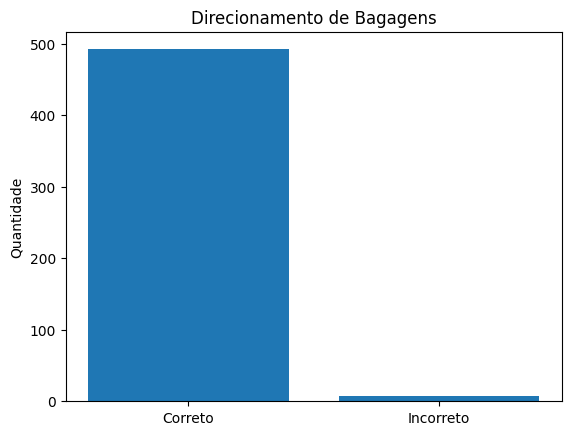

In [17]:
sucessos = np.sum(bagagens)
falhas = n - sucessos

print("Bagagens corretas:", sucessos)
print("Bagagens incorretas:", falhas)

labels = ['Correto', 'Incorreto']
values = [sucessos, falhas]

plt.bar(labels, values)

plt.title("Direcionamento de Bagagens")
plt.ylabel("Quantidade")

plt.show()

### 📊 Conclusão
Cada bagagem foi modelada como um ensaio de Bernoulli, no qual o sucesso corresponde ao direcionamento correto da bagagem para seu destino. Considerando uma probabilidade de sucesso de 98,4%, foram simuladas 500 bagagens.

A taxa observada de direcionamento correto foi próxima do valor esperado, indicando que o sistema apresenta alta eficiência. Falhas de direcionamento ocorrem com baixa frequência, o que sugere que o sistema de triagem de bagagens opera com elevado nível de confiabilidade.

## 🔎 Distribuição Multinomial: Seleção de Portões de Embarque

É basicamente uma **generalização da binomial.**

* **Binomial** → dois resultados possíveis
* **Multinomial** → mais de dois resultados possíveis

A alocação de voos aos portões pode ser modelada por uma distribuição multinomial, pois cada voo pode ser direcionado para um entre vários portões possíveis. Considerando um total de 120 voos e probabilidades pré-definidas de utilização para cinco portões, foi realizada uma simulação da distribuição diária de voos.

Exemplo:

Portão | Probabilidade
---|----
A|30%
B|25%
C|20%
D|15%
E|10%


In [18]:
np.random.seed(42)

voos = 120

prob_portoes = [0.30, 0.25, 0.20, 0.15, 0.10]

### 📌 Simulação da distribuição multinomial

In [19]:
alocacao = np.random.multinomial(voos, prob_portoes)

print(alocacao)

[36 33 24 19  8]


In [20]:
portoes = ['A','B','C','D','E']

df_portoes = pd.DataFrame({
    "Portão": portoes,
    "Voos": alocacao
})

df_portoes

,Portão,Voos
0,A,36
1,B,33
2,C,24
3,D,19
4,E,8


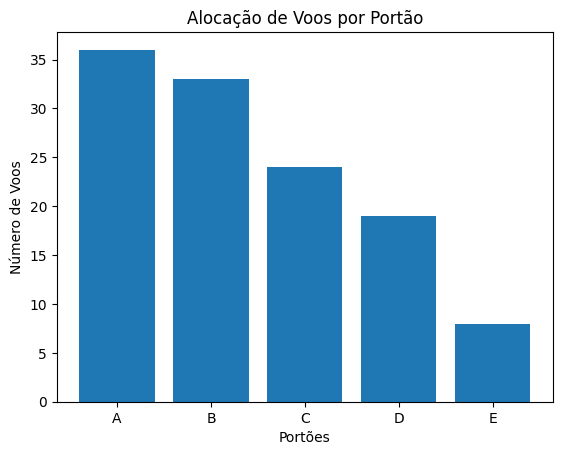

In [21]:
plt.bar(portoes, alocacao)

plt.title("Alocação de Voos por Portão")
plt.xlabel("Portões")
plt.ylabel("Número de Voos")

plt.show()

### 📊 Conclusão

Os resultados mostram que os portões com maior probabilidade de utilização tendem a concentrar maior número de voos, enquanto portões com menor probabilidade apresentam menor ocupação. Esse tipo de modelagem permite avaliar a distribuição esperada de voos e pode auxiliar no planejamento da infraestrutura aeroportuária, evitando sobrecarga em determinados portões e melhorando a eficiência operacional.

## 🔎 Distribuição Geométrica: Primeira Ocorrência de Falha no Sistema de Bagagens

O tempo até a primeira falha do sistema de transporte de bagagens foi modelado utilizando a distribuição geométrica. Esse modelo é apropriado quando se deseja estimar o número de ensaios independentes até a ocorrência do primeiro evento de interesse.

Considerando uma probabilidade diária de falha de 2%, o valor esperado de dias até a primeira falha é de aproximadamente 50 dias. As simulações realizadas apresentaram média próxima desse valor teórico, indicando consistência entre o modelo e os resultados observados.

* Cada **dia de operação** é um ensaio.
* Existem dois resultados:
    * sucesso → ocorreu falha
    * falha → sistema funcionou normalmente 
<br>

* **Quantos dias passam até a primeira falha ocorrer.**

Supondo uma **probabilidade de falha diária** em um dia seja 2%.


### 📌 Simulação de dias até a primeira falha

In [22]:
np.random.seed(42)

p = 0.02  # probabilidade de falha por dia

dias_ate_falha = np.random.geometric(p)

print("Dias até a primeira falha:", dias_ate_falha)

Dias até a primeira falha: 24


### 📌 Simulação de cenários

In [23]:
simulacoes = np.random.geometric(p, size=1000)

ERROR! Session/line number was not unique in database. History logging moved to new session 2


### 📌 Média simulada

In [24]:
media_dias = np.mean(simulacoes)

print("Média estimada de dias até falha:", media_dias)

Média estimada de dias até falha: 48.632


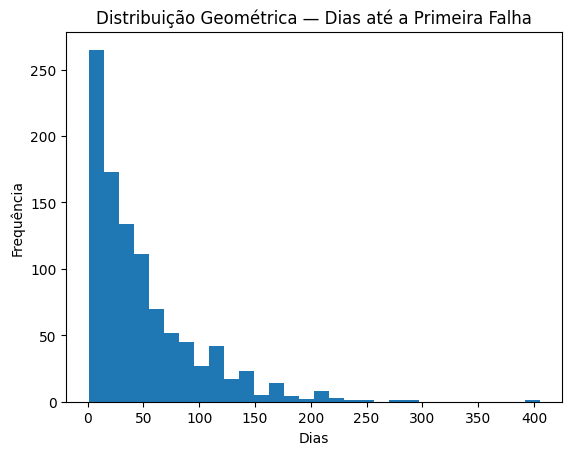

In [25]:
plt.hist(simulacoes, bins=30)

plt.title("Distribuição Geométrica — Dias até a Primeira Falha")
plt.xlabel("Dias")
plt.ylabel("Frequência")

plt.show()

### 📊 Conclusão

Essa análise pode auxiliar na definição de estratégias de manutenção preventiva, permitindo estimar intervalos razoáveis para inspeções e monitoramento do sistema. 
A distribuição geométrica tem uma propriedade interessante chamada memória curta (memoryless).

Isso significa que mesmo que o sistema funcione 30 dias sem falhar, a probabilidade de falhar amanhã continua sendo 2%.